# **Q1:Linear Regression**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [ ]:
X = np.array([
    [2],
    [3],
    [5],
    [7],
    [9],
    [11],
    [13]
])

y = np.array([
    55,
    62,
    73,
    80,
    88,
    92,
    95
])

In [ ]:
#Add column
X_b = np.c_[
    np.ones((X.shape[0], 1)),
    X
]

print("X with bias column:")
print(X_b)

X with bias column:
[[ 1.  2.]
 [ 1.  3.]
 [ 1.  5.]
 [ 1.  7.]
 [ 1.  9.]
 [ 1. 11.]
 [ 1. 13.]]


In [ ]:
# Normal Equation
# theta = (X^T X)^-1 X^T y
theta = np.linalg.inv(
    X_b.T @ X_b
) @ X_b.T @ y

# Intercept and Slope

intercept = theta[0]
slope = theta[1]

print("\n Linear Regression From Scratch")

print("Intercept:", intercept)
print("Slope:", slope)

#predict
hours = 8

prediction_scratch = (
    intercept + slope * hours
)

print(
    "Prediction for 8 hours:",
    prediction_scratch
)




 Linear Regression From Scratch
Intercept: 51.855524079320105
Slope: 3.640226628895191
Prediction for 8 hours: 80.97733711048164


In [ ]:
# Scikit-Learn Linear Regression
model = LinearRegression()

model.fit(X, y)

# Get Sklearn Parameters
sklearn_intercept = model.intercept_
sklearn_slope = model.coef_[0]

prediction_sklearn = model.predict(
    [[8]]
)[0]


# Print Sklearn Results

print("\n Scikit-Learn Linear Regression ")

print(
    "Intercept:",sklearn_intercept
)

print(
    "Slope:",sklearn_slope
)

print(
    "Prediction for 8 hours:",prediction_sklearn
)




 Scikit-Learn Linear Regression 
Intercept: 51.85552407932013
Slope: 3.6402266288951823
Prediction for 8 hours: 80.97733711048159


In [ ]:

# Side-by-Side Comparison

print("\n Comparison ")

print(
    f"{'':20} {'From Scratch':>15} {'Sklearn':>15}"
)

print(
    f"{'Intercept':20} "
    f"{intercept:15.6f} "
    f"{sklearn_intercept:15.6f}"
)

print(
    f"{'Slope':20} "
    f"{slope:15.6f} "
    f"{sklearn_slope:15.6f}"
)

print(
    f"{'Prediction (8 hrs)':20} "
    f"{prediction_scratch:15.6f} "
    f"{prediction_sklearn:15.6f}"
)



 Comparison 
                        From Scratch         Sklearn
Intercept                  51.855524       51.855524
Slope                       3.640227        3.640227
Prediction (8 hrs)         80.977337       80.977337


# **Q2:Polynomial Regression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [ ]:
X = np.array([
    [2],
    [3],
    [5],
    [7],
    [9],
    [11],
    [13]
])

y = np.array([
    55,
    62,
    73,
    80,
    88,
    92,
    95
])


In [ ]:
poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_poly = poly.fit_transform(X)

print("Polynomial Features:")
print(X_poly)

Polynomial Features:
[[2.000e+00 4.000e+00 8.000e+00]
 [3.000e+00 9.000e+00 2.700e+01]
 [5.000e+00 2.500e+01 1.250e+02]
 [7.000e+00 4.900e+01 3.430e+02]
 [9.000e+00 8.100e+01 7.290e+02]
 [1.100e+01 1.210e+02 1.331e+03]
 [1.300e+01 1.690e+02 2.197e+03]]


In [ ]:
# Train Polynomial Regression
poly_model = LinearRegression()

poly_model.fit(X_poly,y)

#Train Simple Linear Regression
linear_model = LinearRegression()

linear_model.fit(X, y)

# Predictions on Original Data
y_poly_pred = poly_model.predict(X_poly)

y_linear_pred = linear_model.predict(X)

In [ ]:
# R2 Scores

r2_poly = r2_score(y,y_poly_pred)

r2_linear = r2_score( y,  y_linear_pred)

print("\n R2 Scores ")

print("Polynomial Regression R2:", r2_poly)

print("Linear Regression R2:",  r2_linear)


 R2 Scores 
Polynomial Regression R2: 0.9987277310738937
Linear Regression R2: 0.955410788016812


In [ ]:
# 7. Create X_new

X_new = np.linspace( 1, 15,  100).reshape(-1, 1)

#  Polynomial Predictions

X_new_poly = poly.transform(   X_new)

y_new_poly = poly_model.predict( X_new_poly)

# Linear Predictions

y_new_linear = linear_model.predict( X_new)


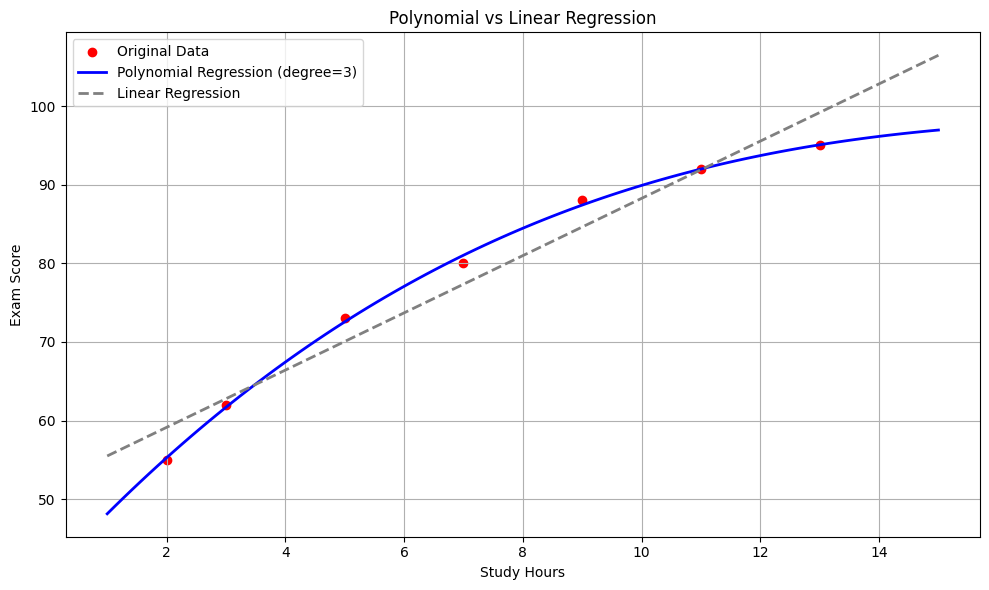

In [ ]:
#plot
plt.figure(figsize=(10, 6))


# Original data points
plt.scatter(
    X,
    y,
    color='red',
    marker='o',
    label='Original Data'
)


# Polynomial curve
plt.plot(
    X_new,
    y_new_poly,
    color='blue',
    linewidth=2,
    label='Polynomial Regression (degree=3)'
)
# Linear regression line
plt.plot(
    X_new,
    y_new_linear,
    color='gray',
    linestyle='--',
    linewidth=2,
    label='Linear Regression'
)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.title(
    "Polynomial vs Linear Regression"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# **Q3:Logistic Regression**

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])
pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = pipe.predict(X_test)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)


Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# Get Prediction Probabilities

y_prob = pipe.predict_proba(
    X_test
)[:, 1]

print("\nFirst 10 prediction probabilities:")
print(y_prob[:10])



First 10 prediction probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [ ]:
#Test Different Thresholds

thresholds = [0.3, 0.5, 0.7]

print("Threshold Comparison")


for threshold in thresholds:

    # Convert probabilities into 0/1 predictions
    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")


Threshold Comparison

Threshold: 0.3
Precision: 0.9730
Recall:    1.0000

Threshold: 0.5
Precision: 0.9861
Recall:    0.9861

Threshold: 0.7
Precision: 0.9853
Recall:    0.9306


# **Q4:Decision Tree**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#load dataset
data = load_breast_cancer()

X = data.data
y = data.target

data.feature_names , data.target_names , X.shape, y.shape

(array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
        'mean smoothness', 'mean compactness', 'mean concavity',
        'mean concave points', 'mean symmetry', 'mean fractal dimension',
        'radius error', 'texture error', 'perimeter error', 'area error',
        'smoothness error', 'compactness error', 'concavity error',
        'concave points error', 'symmetry error',
        'fractal dimension error', 'worst radius', 'worst texture',
        'worst perimeter', 'worst area', 'worst smoothness',
        'worst compactness', 'worst concavity', 'worst concave points',
        'worst symmetry', 'worst fractal dimension'], dtype='<U23'),
 array(['malignant', 'benign'], dtype='<U9'),
 (569, 30),
 (569,))

In [ ]:
#spliting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape


((455, 30), (114, 30))

In [ ]:
#build model
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
#train
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
#prediction
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [ ]:
#Top5 important features
importance = pd.Series(
    model.feature_importances_,
    index=data.feature_names
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop 5 Most Important Features:")
print(importance.head(5))


Top 5 Most Important Features:
worst radius            0.733548
worst concave points    0.122028
texture error           0.045785
worst texture           0.032319
worst concavity         0.017161
dtype: float64


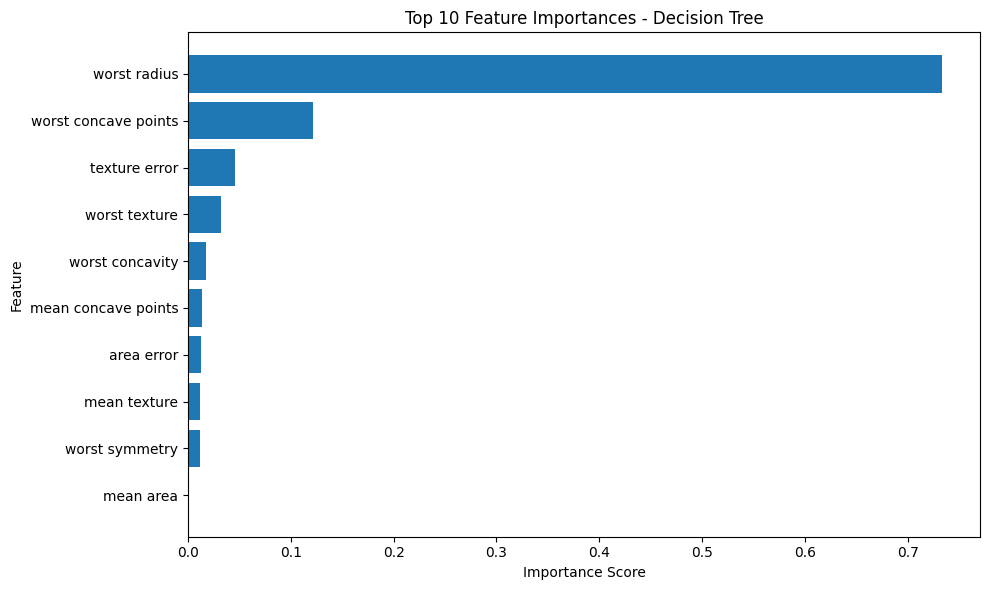

In [ ]:
#plot
top10 = importance.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10.values
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Decision Tree")

plt.tight_layout()
plt.show()


In [ ]:
#accuracy
train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)
print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)


Train Accuracy: 0.9868131868131869
Test Accuracy: 0.9385964912280702


In [ ]:
#gap
gap = train_accuracy - test_accuracy

print("\nTrain-Test Accuracy Gap:", gap)

if gap > 0.05:
    print("Observation: There is a noticeable gap, suggesting possible overfitting.")
else:
    print("Observation: The train-test gap is relatively small.")


Train-Test Accuracy Gap: 0.04821669558511665
Observation: The train-test gap is relatively small.


# **Q5:Random Forest**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,StratifiedKFold,cross_val_score)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score)

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#build model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
#train
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
#predict
y_pred=model.predict(X_test)

#confusion matrix
cm = confusion_matrix(y_test,y_pred)

cm


array([[39,  3],
       [ 2, 70]])

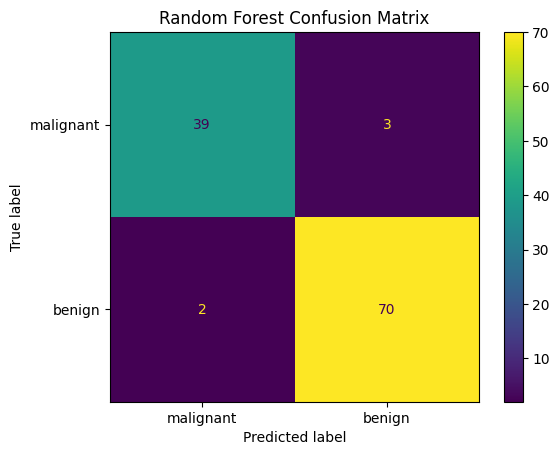

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)


TN: 39
FP: 3
FN: 2
TP: 70


In [ ]:
# manual Precision
precision_manual = TP / (TP + FP)

# manual Recall
recall_manual = TP / (TP + FN)

# manual F1 Score
f1_manual = ( 2 * precision_manual * recall_manual
             /(precision_manual + recall_manual)
)

print("\nManual Metrics:")
print("Precision:", precision_manual)
print("Recall:", recall_manual)
print("F1 Score:", f1_manual)



Manual Metrics:
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


In [ ]:
 # Sklearn Metrics
precision_sklearn = precision_score(y_test, y_pred)

recall_sklearn = recall_score(y_test,y_pred)

f1_sklearn = f1_score(y_test,y_pred)

print("\nSklearn Metrics:")
print("Precision:", precision_sklearn)
print("Recall:", recall_sklearn)
print("F1 Score:", f1_sklearn)


Sklearn Metrics:
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


In [ ]:
# Manual vs Sklearn

print("Precision match:",np.isclose(precision_manual,precision_sklearn))

print("Recall match:",np.isclose(recall_manual,recall_sklearn))

print("F1 match:",np.isclose(f1_manual,f1_sklearn))


Precision match: True
Recall match: True
F1 match: True


In [ ]:
#  5-Fold Stratified Cross Validation

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

scores = cross_val_score(model,X, y, cv=cv,scoring="accuracy")

print("\n5-Fold Cross Validation:")
print("Fold accuracies:", scores)

print(f"Mean Accuracy: {scores.mean():.4f} "
f"+/- {scores.std():.4f}")


5-Fold Cross Validation:
Fold accuracies: [0.96491228 0.93859649 0.95614035 0.94736842 0.96460177]
Mean Accuracy: 0.9543 +/- 0.0102


# **Q6:KNN**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Scale the Data
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
ks = []
accuracies = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled,y_train)

    y_pred = knn.predict( X_test_scaled)

    accuracy = accuracy_score( y_test,y_pred)

    ks.append(k)
    accuracies.append(accuracy)

    print(f"K = {k:2d} | "
        f"Accuracy = {accuracy:.4f}")



K =  1 | Accuracy = 0.9386
K =  2 | Accuracy = 0.9298
K =  3 | Accuracy = 0.9825
K =  4 | Accuracy = 0.9474
K =  5 | Accuracy = 0.9561
K =  6 | Accuracy = 0.9561
K =  7 | Accuracy = 0.9737
K =  8 | Accuracy = 0.9737
K =  9 | Accuracy = 0.9737
K = 10 | Accuracy = 0.9649
K = 11 | Accuracy = 0.9737
K = 12 | Accuracy = 0.9737
K = 13 | Accuracy = 0.9737
K = 14 | Accuracy = 0.9649
K = 15 | Accuracy = 0.9737
K = 16 | Accuracy = 0.9737
K = 17 | Accuracy = 0.9825
K = 18 | Accuracy = 0.9825
K = 19 | Accuracy = 0.9737
K = 20 | Accuracy = 0.9737
K = 21 | Accuracy = 0.9649
K = 22 | Accuracy = 0.9649
K = 23 | Accuracy = 0.9561
K = 24 | Accuracy = 0.9649
K = 25 | Accuracy = 0.9649
K = 26 | Accuracy = 0.9561
K = 27 | Accuracy = 0.9474
K = 28 | Accuracy = 0.9561
K = 29 | Accuracy = 0.9474
K = 30 | Accuracy = 0.9474


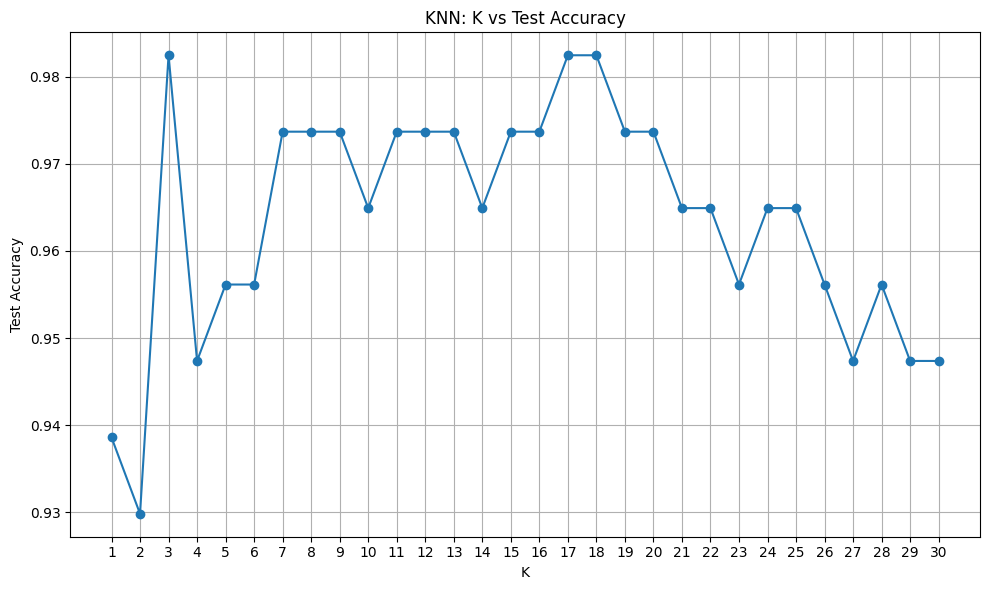

In [ ]:
# Plot K vs Accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    ks,
    accuracies,
    'o-'
)

plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("KNN: K vs Test Accuracy")

plt.xticks(range(1, 31))

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Find Best K
best_index = np.argmax(accuracies)

best_k = ks[best_index]
best_accuracy = accuracies[best_index]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)



Best K: 3
Best Accuracy: 0.9824561403508771


In [ ]:
#Train KNN Using Best K
best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Final Predictions
best_pred = best_knn.predict(X_test_scaled)

In [ ]:
# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred,
        target_names=data.target_names
    )
)


Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# **Q7:K-Means**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

print("Dataset shape:", X.shape)

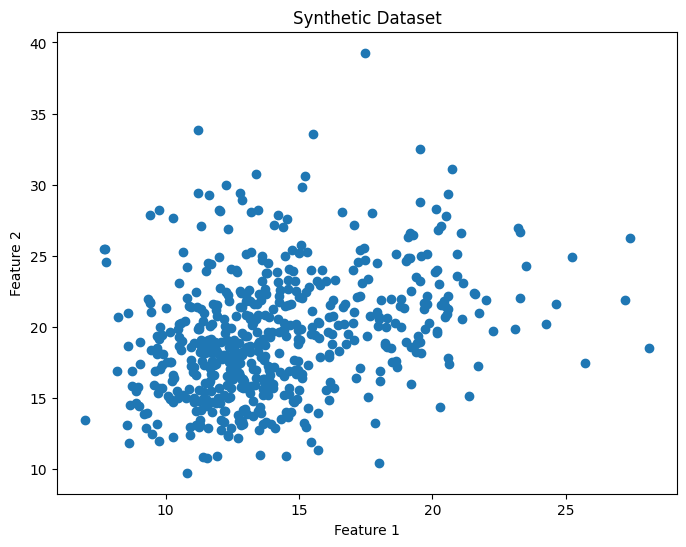

In [ ]:
# Visualize Original Dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset")

plt.show()


In [ ]:
# Run K-Means for K = 2 to 6
ks = [2, 3, 4, 5, 6]

inertias = []

print("\nInertia for each K:")

for k in ks:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia = kmeans.inertia_

    inertias.append(inertia)

    print(
        f"K = {k} | "
        f"Inertia = {inertia:.2f}"
    )


Inertia for each K:
K = 2 | Inertia = 77943099.88
K = 3 | Inertia = 47264841.92
K = 4 | Inertia = 29226541.65
K = 5 | Inertia = 20539877.62
K = 6 | Inertia = 16573867.02


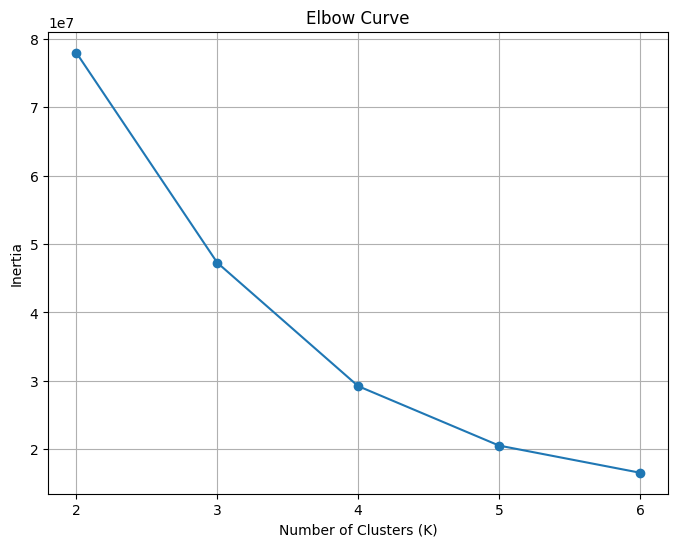

In [ ]:
#Plot Elbow Curve
plt.figure(figsize=(8, 6))

plt.plot(
    ks,
    inertias,
    'o-'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")

plt.xticks(ks)
plt.grid(True)

plt.show()


In [ ]:
# Choose Best K
# The dataset was generated with 4 centers,
# and the elbow should appear around K = 4.

best_k = 4

print("\nSelected K:", best_k)


Selected K: 4


In [ ]:
# Train Final K-Means Model

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = kmeans_final.fit_predict(X)

centroids = kmeans_final.cluster_centers_

# Print Centroids

print("\nCluster Centroids:")

print(centroids)


Cluster Centroids:
[[1.13746604e+01 1.80338060e+01 7.29983582e+01 4.01888806e+02
  9.41407836e-02 7.99884701e-02 4.49432974e-02 2.35119478e-02
  1.77566418e-01 6.44091045e-02 2.83132836e-01 1.30673433e+00
  1.98523806e+00 1.96542090e+01 7.87391791e-03 2.21788507e-02
  2.71027037e-02 9.83715299e-03 2.21019403e-02 3.87190858e-03
  1.25300336e+01 2.37872015e+01 8.12810075e+01 4.84963433e+02
  1.28405000e-01 1.82591978e-01 1.63309616e-01 6.94225037e-02
  2.76479104e-01 8.14750746e-02]
 [2.34015789e+01 2.27621053e+01 1.56147368e+02 1.72942105e+03
  1.04154211e-01 1.71922105e-01 2.39015789e-01 1.34857895e-01
  1.85884211e-01 5.91452632e-02 1.19100000e+00 1.25407895e+00
  8.56357895e+00 1.91449474e+02 7.10673684e-03 3.64242105e-02
  4.79426316e-02 1.59331579e-02 2.00326316e-02 3.80478947e-03
  2.99315789e+01 3.02952632e+01 2.03073684e+02 2.76584211e+03
  1.41510526e-01 3.89415789e-01 5.05994737e-01 2.27526316e-01
  2.89852632e-01 8.18736842e-02]
 [1.89783168e+01 2.16180198e+01 1.25336634e+02

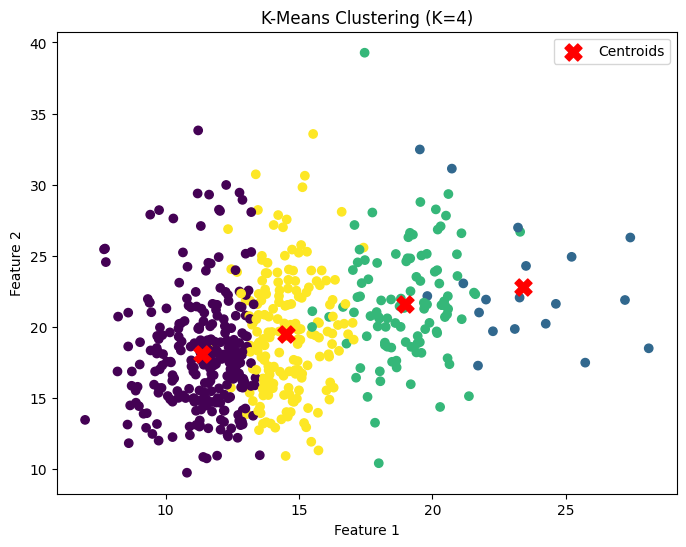

In [ ]:
# Plot Clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=150,
    color='red',
    label='Centroids'
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering (K=4)")
plt.legend()

plt.show()

In [ ]:
#Calculate Silhouette Score
silhouette = silhouette_score(
    X,
    labels
)

print("\nSilhouette Score:", silhouette)


Silhouette Score: 0.5334614737117133


# **Q8:PCA**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled training shape:", X_train_scaled.shape)


Scaled training shape: (455, 30)


In [ ]:
#model
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)


In [ ]:
# Explained Variance Ratio

print("\nExplained Variance Ratio - First 10 Components:")

for i, variance in enumerate(
    pca.explained_variance_ratio_[:10],
    start=1
):
    print(
        f"PC{i}: {variance:.4f}"
    )


Explained Variance Ratio - First 10 Components:
PC1: 0.4441
PC2: 0.1894
PC3: 0.0954
PC4: 0.0672
PC5: 0.0552
PC6: 0.0393
PC7: 0.0218
PC8: 0.0158
PC9: 0.0128
PC10: 0.0115


In [ ]:
# Cumulative Explained Variance

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("\nCumulative variance after first 10 components:")

for i in range(10):
    print(
        f"{i + 1} components: "
        f"{cumulative_variance[i]:.4f}"
    )


Cumulative variance after first 10 components:
1 components: 0.4441
2 components: 0.6336
3 components: 0.7290
4 components: 0.7963
5 components: 0.8514
6 components: 0.8908
7 components: 0.9126
8 components: 0.9284
9 components: 0.9412
10 components: 0.9527


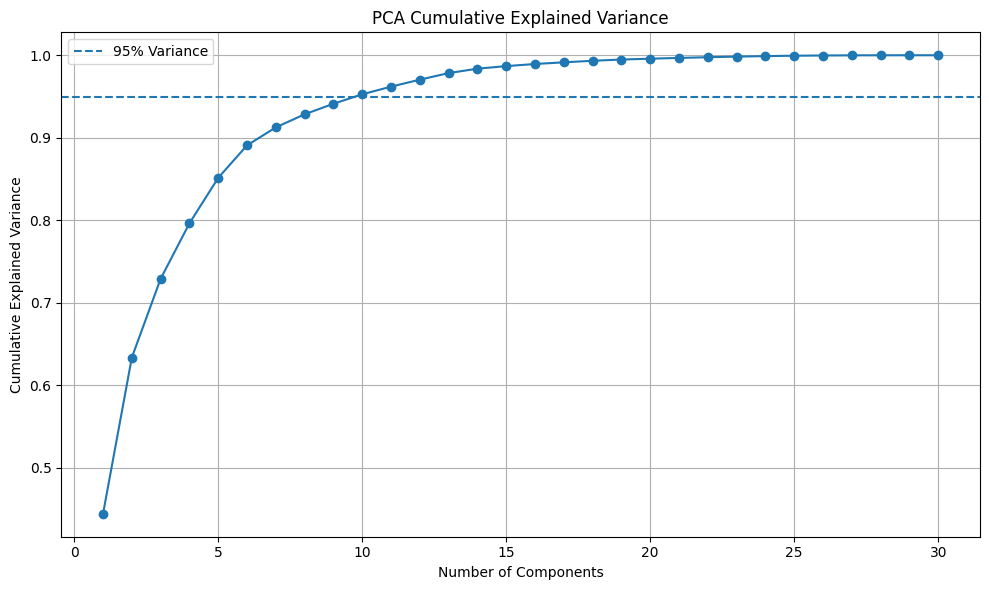

In [ ]:
# Plot Cumulative Explained Variance
components = np.arange(
    1,
    len(cumulative_variance) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    components,
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Number of Components for 95% Variance
n_components_95 = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)

print(
    "\nNumber of components needed "
    "for at least 95% variance:",
    n_components_95
)


Number of components needed for at least 95% variance: 10


In [ ]:
#PCA to 2 Principal Components
pca_2d = PCA(
    n_components=2
)

X_train_2d = pca_2d.fit_transform(
    X_train_scaled
)

print(
    "\n2D PCA shape:",
    X_train_2d.shape
)


2D PCA shape: (455, 2)


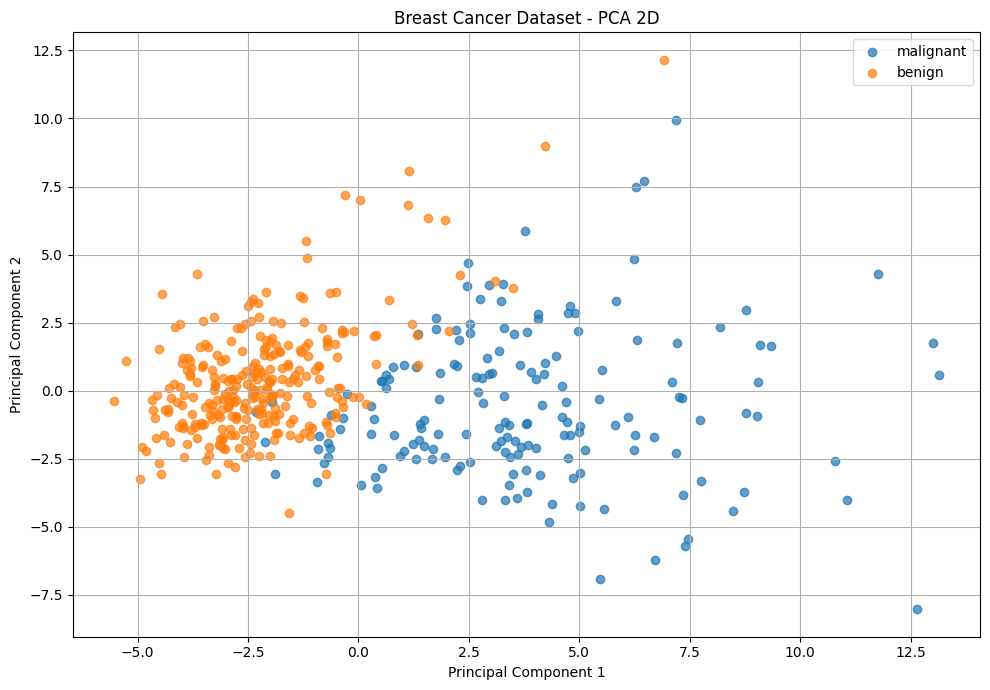

In [ ]:
# Plot PCA 2D
plt.figure(figsize=(10, 7))

for class_value, class_name in enumerate(
    data.target_names
):

    mask = y_train == class_value

    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Breast Cancer Dataset - PCA 2D"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Take First Test Sample
first_test_sample = X_test_scaled[0].reshape(1,-1)

print("\nOriginal scaled sample shape:",first_test_sample.shape)


Original scaled sample shape: (1, 30)


In [ ]:
#Reduce First Test Sample to 2D
sample_2d = pca_2d.transform(first_test_sample)

print("Reduced sample shape:",sample_2d.shape)

print("2D representation:",sample_2d)

Reduced sample shape: (1, 2)
2D representation: [[ 6.41553764 -2.04029192]]


In [ ]:
#Reconstruct Sample Back to 30D
sample_reconstructed = (
    pca_2d.inverse_transform(
        sample_2d))

print("\nReconstructed sample shape:",sample_reconstructed.shape)


Reconstructed sample shape: (1, 30)


In [ ]:
# Calculate Reconstruction MSE
mse = np.mean(
    (
        first_test_sample
        - sample_reconstructed
    ) ** 2)

print("\nReconstruction MSE:",mse)


Reconstruction MSE: 0.27712424027366833


# **Q9:Pipelines**

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import classification_report

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
     X,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
#Build Pipeline
pipe = Pipeline([
    ('scaler',StandardScaler()),

    ('pca',PCA(n_components=0.95)),

    ( 'svc',SVC( kernel='rbf'))
])
#fit
pipe.fit(X_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('svc', SVC())])

In [ ]:
#predict
y_pred = pipe.predict(X_test)

#classification repot
print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(pipe,X,y,cv=5,scoring='f1_macro'
)
print("5-Fold Cross Validation")

print("F1 Macro scores:", cv_scores)

print(
    f"Mean F1 Macro: "
    f"{cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{cv_scores.std():.4f}"
)

print(
    f"Mean ± Std: "
    f"{cv_scores.mean():.4f} "
    f"+/- "
    f"{cv_scores.std():.4f}"
)

5-Fold Cross Validation
F1 Macro scores: [0.97212032 0.96230159 0.99052763 0.9712774  0.98122924]
Mean F1 Macro: 0.9755
Standard Deviation: 0.0096
Mean ± Std: 0.9755 +/- 0.0096


In [ ]:
# Number of PCA Components
pca_fitted = pipe.named_steps['pca']

print("PCA Information")

print(
    "Original number of features:",
    X.shape[1]
)

print(
    "Number of PCA components kept:",
    pca_fitted.n_components_
)

print(
    "Explained variance:",
    pca_fitted.explained_variance_ratio_.sum()
)

PCA Information
Original number of features: 30
Number of PCA components kept: 10
Explained variance: 0.9526768937417546


# **Q10:End2eEnd Challenge**

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error ,r2_score

In [8]:
import kagglehub
dataset_path = kagglehub.dataset_download('zafarali27/house-price-prediction-dataset')


Using Colab cache for faster access to the 'house-price-prediction-dataset' dataset.


In [9]:
import os

print(os.listdir(dataset_path))

['House Price Prediction Dataset.csv']


In [11]:
file_path = os.path.join(
    dataset_path,
    "House Price Prediction Dataset.csv"
)

df = pd.read_csv(file_path)
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [13]:
df.shape

(2000, 10)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [15]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [16]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [27]:
X = df.drop(
    "Price",
    axis=1
)

y = df["Price"]
X = X.drop("Id", axis=1)

In [28]:
# Numeric columns
numeric_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]


# Categorical columns
categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

In [29]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
model.fit(X_train ,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [31]:
y_pred = model.predict(X_test)

In [33]:
mae = mean_absolute_error( y_test, y_pred)

rmse = np.sqrt(mean_squared_error(  y_test, y_pred ))

r2 = r2_score( y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 252671.95184999998
RMSE: 292329.6266654516
R2  : -0.09843055804502554


In [37]:
preprocessor_fitted = (
    model.named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)
rf = model.named_steps[
    "regressor"
]

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances
})


# Sort descending

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)



In [38]:
print(
    feature_importance_df.head(5).to_string(
        index=False
    )
)

           Feature  Importance
     numeric__Area    0.323898
numeric__YearBuilt    0.262667
 numeric__Bedrooms    0.094241
numeric__Bathrooms    0.071979
   numeric__Floors    0.047900
